In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from scipy import stats
%matplotlib inline
sns.set(style = "darkgrid", font_scale = 1.5)
pd.set_option("display.max.columns", None)
pd.set_option("display.max.rows", None)

import warnings
warnings.filterwarnings("ignore")

## Health Indicators

Life expectancy → Average number of years a person is expected to live in that country for that year.

Adult Mortality → Probability of dying between ages 15 and 60 per 1000 population (higher means worse health outcomes).

infant deaths → Number of deaths of infants (age < 1 year) per 1000 population.

under-five deaths → Number of deaths of children under age 5 per 1000 population.

HIV/AIDS → Deaths per 1000 people due to HIV/AIDS.

thinness 1-19 years → Percentage of population aged 1–19 who are underweight.

thinness 5-9 years → Percentage of children aged 5–9 who are underweight.


## Immunization Coverage

Hepatitis B → Percentage of 1-year-old children immunized against Hepatitis B.

Polio → Percentage of 1-year-old children immunized against Polio.

Diphtheria → Percentage of 1-year-old children immunized against Diphtheria, Pertussis (whooping cough), and Tetanus (DPT).

Measles → Number of reported measles cases per 1000 population.


## Lifestyle / Health Expenditure

Alcohol → Per capita (average per person) consumption of alcohol in liters per year.

BMI → Average Body Mass Index of the population.

percentage expenditure → Expenditure on health as a percentage of GDP per capita.

Total expenditure → Government expenditure on health as a percentage of total government expenditure.


## Economy & Resources

GDP → Gross Domestic Product per capita (in USD).

Income composition of resources → Human Development Index (HDI)-like measure of income composition (values between 0 and 1, higher is better).

Schooling → Average number of years of schooling in the population.

Population → Population of the country for that year.

In [50]:
df = pd.read_csv("data_life_expectancy.zip")
print(df.head(5))

       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2015  Developing              65.0            263.0   
3  Afghanistan  2014  Developing              59.9            271.0   
4  Afghanistan  2015  Developing              65.0            263.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   \
0             62     0.01               71.279624         65.0      1154   
1             64     0.01               73.523582         62.0       492   
2             62     0.01               71.279624         65.0      1154   
3             64     0.01               73.523582         62.0       492   
4             62     0.01               71.279624         65.0      1154   

    BMI   under-five deaths   Polio  Total expenditure  Diphtheria   \
0   19.1                  83    6.0          

In [51]:
# show me any 5 random samples
print(df.sample(5))

      Country  Year      Status  Life expectancy   Adult Mortality  \
944    France  2005  Developing              81.0             93.0   
1824    Nepal  2008  Developing              67.0            189.0   
1801  Namibia  2014  Developing              65.9            242.0   
1282   Israel  2003  Developing              79.7             71.0   
1302  Jamaica  2015  Developing              76.2            125.0   

      infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   \
944               3    12.20             5451.701225         35.0        36   
1824             27     0.21               70.271132         82.0      2089   
1801              2     0.01              751.398272         88.0       477   
1282              1     2.32             1731.755747         98.0       124   
1302              1      NaN                0.000000         91.0         0   

       BMI   under-five deaths   Polio  Total expenditure  Diphtheria   \
944    57.5                   

In [52]:
# clean up column names: Use titles format in column names and strip empty spaces
print("df.columns(BEFORE):",list(df.columns))
df.columns = df.columns.str.strip().str.title()
print()

# Rename one column that has extra space
df.rename(columns = {"Thinness  1-19 Years" : "Thinness 1-19 Years"}, inplace = True)
print("df.columns(AFTER) :",list(df.columns))

df.columns(BEFORE): ['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']

df.columns(AFTER) : ['Country', 'Year', 'Status', 'Life Expectancy', 'Adult Mortality', 'Infant Deaths', 'Alcohol', 'Percentage Expenditure', 'Hepatitis B', 'Measles', 'Bmi', 'Under-Five Deaths', 'Polio', 'Total Expenditure', 'Diphtheria', 'Hiv/Aids', 'Gdp', 'Population', 'Thinness 1-19 Years', 'Thinness 5-9 Years', 'Income Composition Of Resources', 'Schooling']


In [53]:
print(df.info())

# observation: 
# - There are 2942 records in total
# - Some columns like "Life Expectancy", "Alcohol", etc are missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2942 entries, 0 to 2941
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2942 non-null   object 
 1   Year                             2942 non-null   int64  
 2   Status                           2942 non-null   object 
 3   Life Expectancy                  2932 non-null   float64
 4   Adult Mortality                  2932 non-null   float64
 5   Infant Deaths                    2942 non-null   int64  
 6   Alcohol                          2748 non-null   float64
 7   Percentage Expenditure           2942 non-null   float64
 8   Hepatitis B                      2389 non-null   float64
 9   Measles                          2942 non-null   int64  
 10  Bmi                              2908 non-null   float64
 11  Under-Five Deaths                2942 non-null   int64  
 12  Polio               

In [54]:
# I want to know the descritive stats of each numeric column
# print(df.describe())
print(df.describe().T)

# observation: 
# - from year column I see that I have data from 2000 to 2015
# - 

                                  count          mean           std  \
Year                             2942.0  2.007528e+03  4.617912e+00   
Life Expectancy                  2932.0  6.921569e+01  9.521118e+00   
Adult Mortality                  2932.0  1.649359e+02  1.242646e+02   
Infant Deaths                    2942.0  3.034840e+01  1.178524e+02   
Alcohol                          2748.0  4.596175e+00  4.053246e+00   
Percentage Expenditure           2942.0  7.373460e+02  1.986714e+03   
Hepatitis B                      2389.0  8.091126e+01  2.505924e+01   
Measles                          2942.0  2.417421e+03  1.145963e+04   
Bmi                              2908.0  3.829446e+01  2.004324e+01   
Under-Five Deaths                2942.0  4.209347e+01  1.603440e+02   
Polio                            2923.0  8.248101e+01  2.350618e+01   
Total Expenditure                2716.0  5.941476e+00  2.497946e+00   
Diphtheria                       2923.0  8.229832e+01  2.371096e+01   
Hiv/Ai

In [55]:
# Now I want to see the stats on non-numeric columns:
print(df.describe(include = ['object']).T)

# observation:
# - There are total of 193 unique contries
# - Afghanistan is most occuring value in column country with frequency 16
# - Status column has 2 unique values. The value Developing is the most common occuring value with freq = 2426

        count unique          top  freq
Country  2942    193  Afghanistan    20
Status   2942      2   Developing  2430


In [56]:
# step1: Lets print the count of missing values
print(df.isnull().sum())

print("################")
# step2: I want to see the percent of missing values and missing values
# and put it in dataframe. 
# Count of missing values
missing_count = df.isnull().sum()

# Percentage of missing values
missing_percentage = (missing_count / len(df)) * 100

# Combine into one DataFrame for better display
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
})

print(missing_df)

# NOTE: Since this is just EDA, we are not going to do anything about missing values

Country                              0
Year                                 0
Status                               0
Life Expectancy                     10
Adult Mortality                     10
Infant Deaths                        0
Alcohol                            194
Percentage Expenditure               0
Hepatitis B                        553
Measles                              0
Bmi                                 34
Under-Five Deaths                    0
Polio                               19
Total Expenditure                  226
Diphtheria                          19
Hiv/Aids                             0
Gdp                                448
Population                         652
Thinness 1-19 Years                 34
Thinness 5-9 Years                  34
Income Composition Of Resources    167
Schooling                          163
dtype: int64
################
                                 Missing Count  Missing Percentage
Country                                      

In [57]:
# Lets find duplicate values

# step1: find the count of duplicate values
print(df.duplicated().sum())

# step2: I want to see the duplicate values
# Get only duplicate rows
duplicates = df[df.duplicated()]
print(duplicates)

# step3: Drop your duplicate values
df.drop_duplicates(inplace=True)

4
       Country  Year      Status  Life Expectancy  Adult Mortality  \
2  Afghanistan  2015  Developing             65.0            263.0   
3  Afghanistan  2014  Developing             59.9            271.0   
4  Afghanistan  2015  Developing             65.0            263.0   
5  Afghanistan  2014  Developing             59.9            271.0   

   Infant Deaths  Alcohol  Percentage Expenditure  Hepatitis B  Measles   Bmi  \
2             62     0.01               71.279624         65.0     1154  19.1   
3             64     0.01               73.523582         62.0      492  18.6   
4             62     0.01               71.279624         65.0     1154  19.1   
5             64     0.01               73.523582         62.0      492  18.6   

   Under-Five Deaths  Polio  Total Expenditure  Diphtheria  Hiv/Aids  \
2                 83    6.0               8.16        65.0       0.1   
3                 86   58.0               8.18        62.0       0.1   
4                 83    6

In [59]:
print(df.head(5))

       Country  Year      Status  Life Expectancy  Adult Mortality  \
0  Afghanistan  2015  Developing             65.0            263.0   
1  Afghanistan  2014  Developing             59.9            271.0   
6  Afghanistan  2013  Developing             59.9            268.0   
7  Afghanistan  2012  Developing             59.5            272.0   
8  Afghanistan  2011  Developing             59.2            275.0   

   Infant Deaths  Alcohol  Percentage Expenditure  Hepatitis B  Measles   Bmi  \
0             62     0.01               71.279624         65.0     1154  19.1   
1             64     0.01               73.523582         62.0      492  18.6   
6             66     0.01               73.219243         64.0      430  18.1   
7             69     0.01               78.184215         67.0     2787  17.6   
8             71     0.01                7.097109         68.0     3013  17.2   

   Under-Five Deaths  Polio  Total Expenditure  Diphtheria  Hiv/Aids  \
0                 83

In [60]:
# Lets create a df that contains numeric values
numerical_df = df.select_dtypes(include = [np.number])
print(numerical_df.head(5))

,Year,Life Expectancy,Adult Mortality,Infant Deaths,Alcohol,Percentage Expenditure,Hepatitis B,Measles,Bmi,Under-Five Deaths,Polio,Total Expenditure,Diphtheria,Hiv/Aids,Gdp,Population,Thinness 1-19 Years,Thinness 5-9 Years,Income Composition Of Resources,Schooling
0,2015,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
6,2013,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
7,2012,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
8,2011,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [61]:
# Lets create a df that contains categorical values
categorical_df = df.select_dtypes(include = ['object'])
print(categorical_df.head(5))

       Country      Status
0  Afghanistan  Developing
1  Afghanistan  Developing
6  Afghanistan  Developing
7  Afghanistan  Developing
8  Afghanistan  Developing


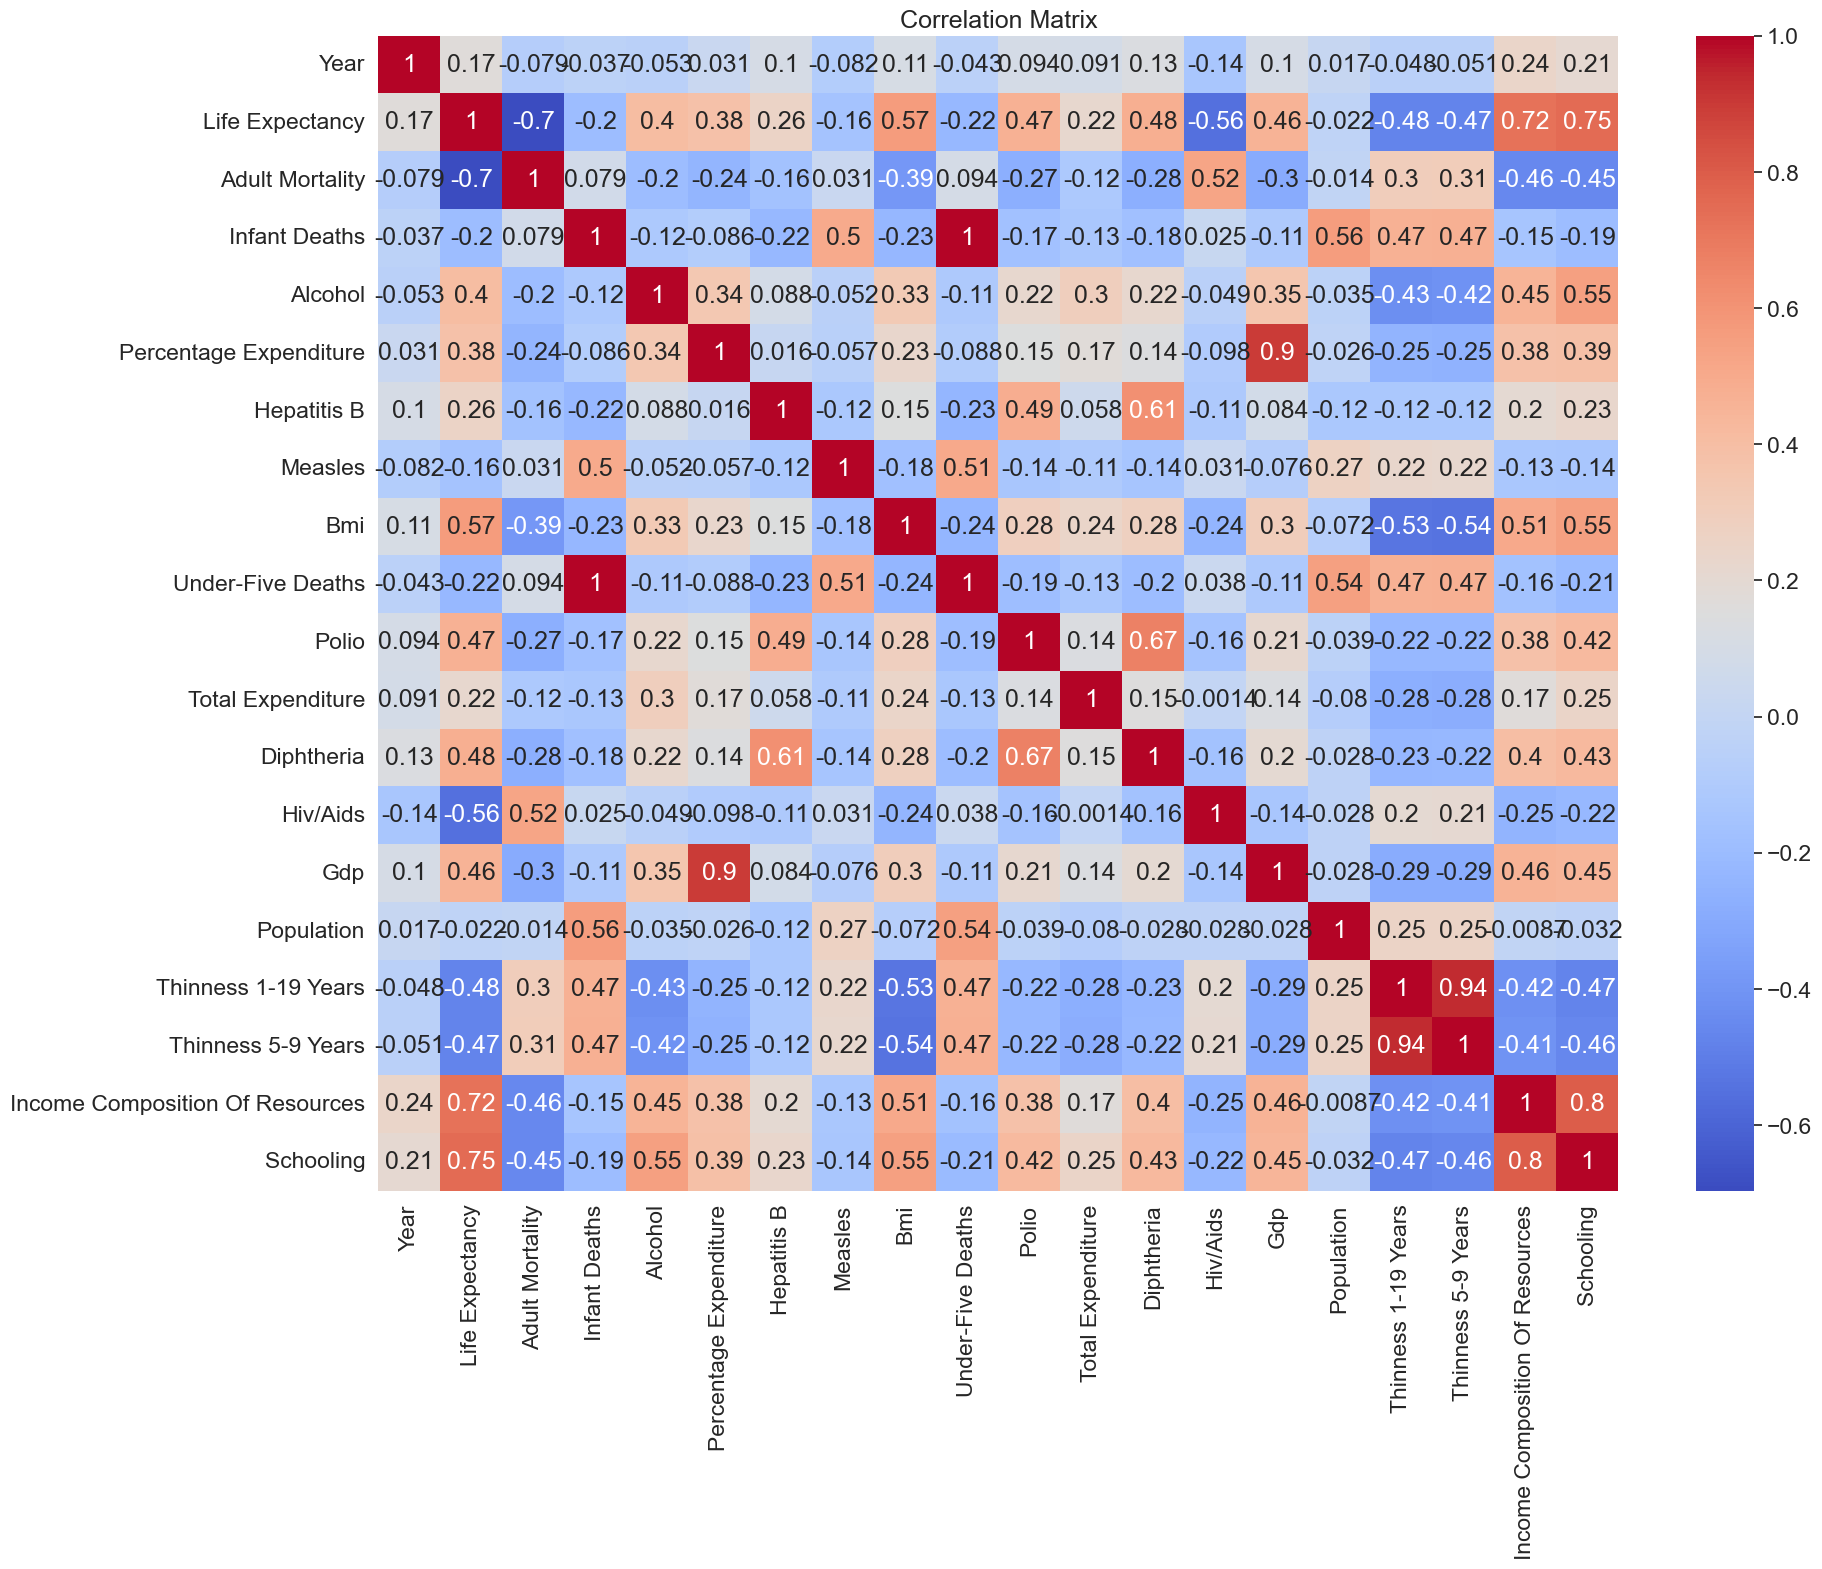

In [63]:
# Lets compute the correlation matrix for numeric columns and visualize it
# BTW, this is bivariate analysis
correlation_matrix = numerical_df.corr(numeric_only=True)

plt.figure(figsize = (20,15))
sns.heatmap(correlation_matrix, annot = True, cmap = "coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Observation:
# There is a very high corelation between
# - infant deaths and under-five deaths
# - percentage expenditure and GDP
# - Income composition of resources and Schooling
# - Life expectancy and Income composition of resources
# - Schooling and Life expectancy
# Column Under 5 death and infant death have corr_coeff = 1. So in essence they are same columns 

### univariate analysis

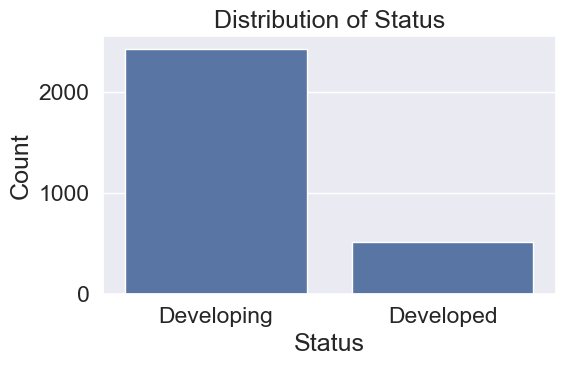

In [66]:
# Step1: lets plot countplot of column Status.
plt.figure(figsize = (6,4))
sns.countplot(x='Status', data=df)
plt.xlabel("Status")
plt.ylabel("Count")
plt.title("Distribution of Status")
plt.tight_layout()
plt.show()

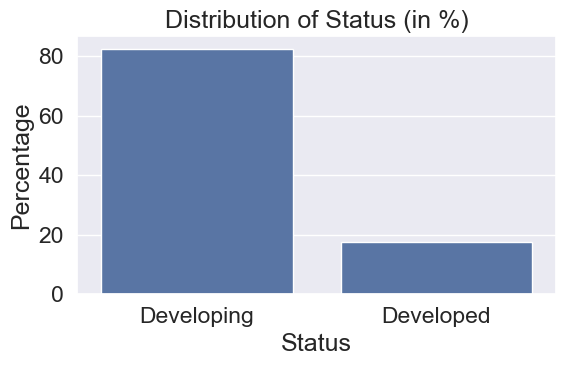

In [67]:
# step2: Now I want to see the percentage
plt.figure(figsize=(6,4))

sns.countplot(x='Status', data=df, stat="percent")  # <-- normalize here

plt.xlabel("Status")
plt.ylabel("Percentage")
plt.title("Distribution of Status (in %)")
plt.tight_layout()
plt.show()

# observation: Developing countries are more compared to the Developed Nation

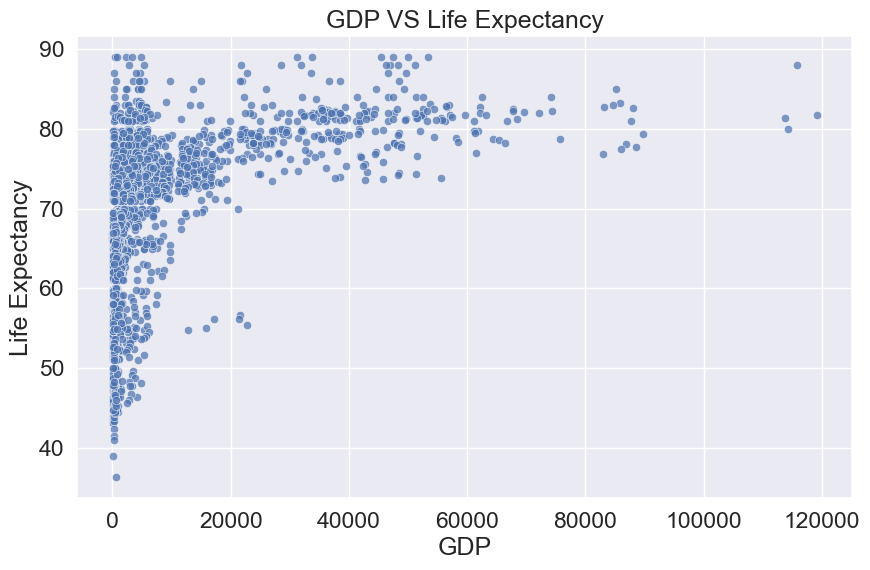

In [71]:
# lets scatterplot "Life Expectancy" and "Gdp": Bivariate analysis
plt.figure(figsize = (10,6))
sns.scatterplot(data = df, x="Gdp", y="Life Expectancy", palette = "virdis", alpha = 0.7)

plt.title("GDP VS Life Expectancy")
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.grid(True)
plt.tight_layout

plt.show()

# observation:
# As GDP goes up, LE goes up too
# Most people live within the Gdp 0-20000

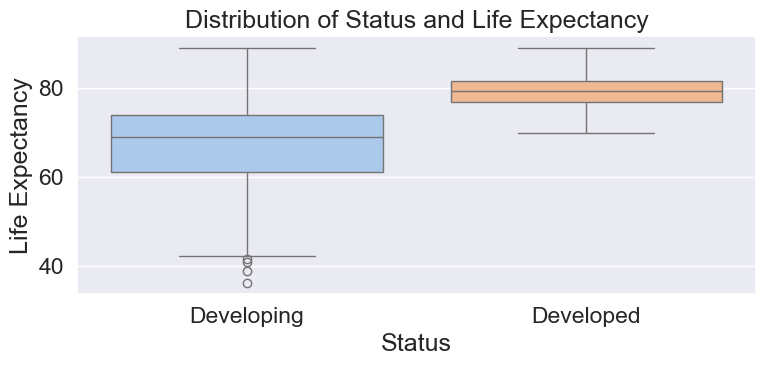

In [72]:
# step1: Lets compare life expectancy of developped and developing countries using boxplot: (Bivariate analysis)
plt.figure(figsize = (8,4))
sns.boxplot(data = df, x="Status", y="Life Expectancy", palette = 'pastel')
plt.title("Distribution of Status and Life Expectancy")
plt.xlabel("Status")
plt.ylabel("Life Expectancy")
plt.tight_layout()
plt.show()

# observation: LE is higher for developed country


In [77]:
# step2: I want to know the exact value of min and max for LE for developed and developing country
df_developing = df[df['Status'] == 'Developing']
print("min for developing=", df_developing['Life Expectancy'].min())
print("max for developing=", df_developing['Life Expectancy'].max())

df_developed = df[df['Status'] == 'Developed']
print("min for developed=", df_developed['Life Expectancy'].min())
print("max for developed=", df_developed['Life Expectancy'].max())

min for developing= 36.3
max for developing= 89.0
min for developed= 69.9
max for developed= 89.0


In [ ]:
## TO BE CONTINUED.....